In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df = pd.read_csv("../data/customer_churn.csv")

In [99]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [101]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [102]:
df['Onboard_date'].head()

0    2013-08-30 07:00:40
1    2013-08-13 00:38:46
2    2016-06-29 06:20:07
3    2014-04-22 12:43:12
4    2016-01-19 15:31:15
Name: Onboard_date, dtype: str

In [103]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'],format='mixed', dayfirst=True)

In [104]:
df['Onboard_date'].dtype

dtype('<M8[us]')

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Names            900 non-null    str           
 1   Age              900 non-null    float64       
 2   Total_Purchase   900 non-null    float64       
 3   Account_Manager  900 non-null    int64         
 4   Years            900 non-null    float64       
 5   Num_Sites        900 non-null    float64       
 6   Onboard_date     900 non-null    datetime64[us]
 7   Location         900 non-null    str           
 8   Company          900 non-null    str           
 9   Churn            900 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(3)
memory usage: 70.4 KB


In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df[df.duplicated()]

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn


In [108]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885


In [109]:
df.head()


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [110]:
df['tenure_group'] = pd.cut(
    df['Years'],
    bins=[0,3,6,10],
    labels=['New','Medium','old']
)

In [111]:
df['tenure_group'].value_counts()

tenure_group
Medium    614
old       244
New        42
Name: count, dtype: int64

In [112]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_group
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,old
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Medium


In [113]:
df.groupby('tenure_group')['Churn'].mean()

tenure_group
New       0.071429
Medium    0.140065
old       0.250000
Name: Churn, dtype: float64

Insight:

Customers with longer tenure show a higher churn rate.

Old customers have a churn rate of 25%, compared to 14% for medium-tenure customers and 7% for new customers.

In [114]:
df.groupby('Account_Manager')['Churn'].mean()

Account_Manager
0    0.141328
1    0.193995
Name: Churn, dtype: float64

Insight:

Customers with account managers have a churn rate of 19.4% compared to 14.1% for customers without account managers.

Further investigation is required to determine whether account managers are assigned to higher-risk customers.

In [115]:
df.groupby("Num_Sites")["Churn"].mean().sort_values(ascending=False)

Num_Sites
13.0    1.000000
12.0    0.843750
14.0    0.833333
11.0    0.554217
10.0    0.259542
9.0     0.102151
8.0     0.037559
6.0     0.014925
7.0     0.013699
5.0     0.000000
3.0     0.000000
4.0     0.000000
Name: Churn, dtype: float64

Insight:

Customers with a higher number of sites are significantly more likely to churn.

Customers with 11+ sites show churn rates above 50%, while customers with fewer than 8 sites rarely churn.

Num_Sites appears to be a strong predictor of customer churn.

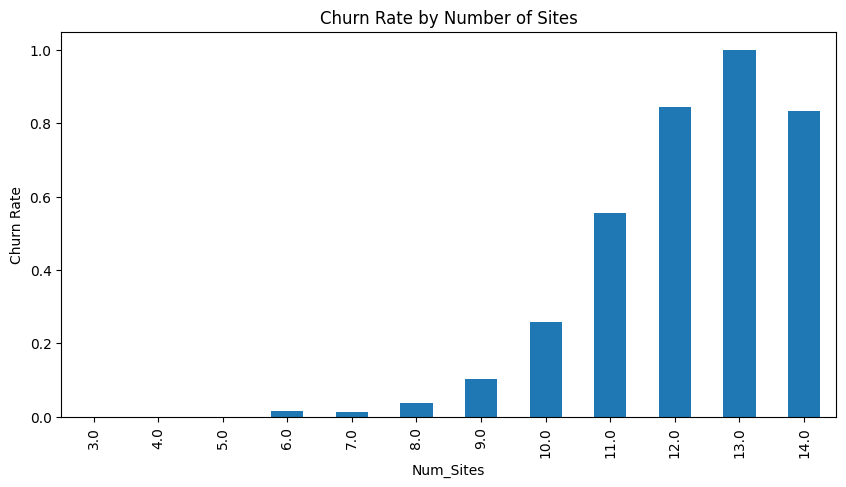

In [116]:
churn_by_sites = df.groupby("Num_Sites")["Churn"].mean()

plt.figure(figsize=(10,5))

churn_by_sites.plot(kind="bar")

plt.title("Churn Rate by Number of Sites")
plt.ylabel("Churn Rate")

plt.show()

In [117]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_group
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,old
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Medium


<Axes: xlabel='Age', ylabel='Count'>

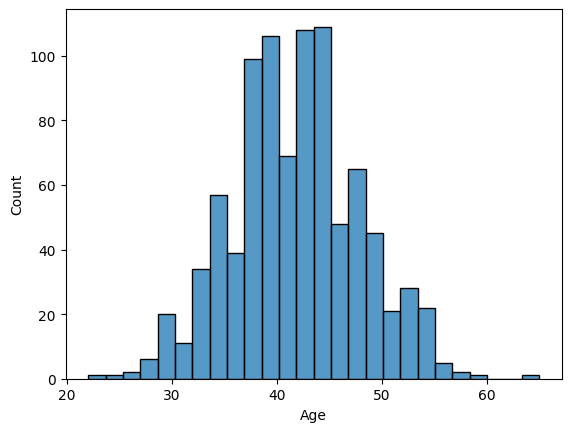

In [118]:
sns.histplot(df['Age'])

(array([  4.,  26.,  70., 218., 235., 186., 122.,  35.,   3.,   1.]),
 array([22. , 26.3, 30.6, 34.9, 39.2, 43.5, 47.8, 52.1, 56.4, 60.7, 65. ]),
 <BarContainer object of 10 artists>)

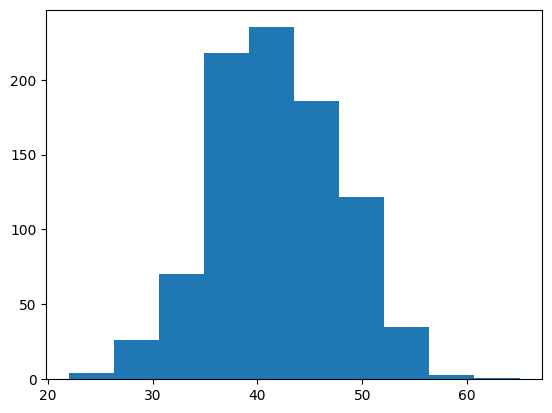

In [119]:
plt.hist(df['Age'])

In [120]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_group
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,old
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Medium


In [121]:
df['Years_x_sites'] = df['Years'] * df['Num_Sites']

In [122]:
df['Years_x_sites'] 

0      57.76
1      71.50
2      80.04
3      67.10
4      50.04
       ...  
895    28.96
896    48.37
897    21.84
898    54.70
899    50.20
Name: Years_x_sites, Length: 900, dtype: float64

In [123]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_group,Years_x_sites
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old,71.50
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old,80.04
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,old,67.10
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Medium,50.04


Interaction features help capture relationships between variables that may not be visible when the variables are used individually.

In [124]:
df['Total_Purchase'].describe()

count      900.000000
mean     10062.824033
std       2408.644532
min        100.000000
25%       8497.122500
50%      10045.870000
75%      11760.105000
max      18026.010000
Name: Total_Purchase, dtype: float64

In [125]:
df['Log_Total_Purchase'] = np.log1p(df['Total_Purchase'])


In [126]:
df.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_group,Years_x_sites,Log_Total_Purchase
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76,9.311795
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old,71.50,9.385740


In [127]:
df[['Total_Purchase','Log_Total_Purchase']].head(20)

,Total_Purchase,Log_Total_Purchase
0,11066.80,9.311795
1,11916.22,9.385740
2,12884.75,9.463877
3,8010.76,8.988666
4,9191.58,9.126152
5,10356.02,9.245420
6,11331.58,9.335437
7,9885.12,9.198887
8,14062.60,9.551345
9,8066.94,8.995653


<Axes: xlabel='Total_Purchase', ylabel='Count'>

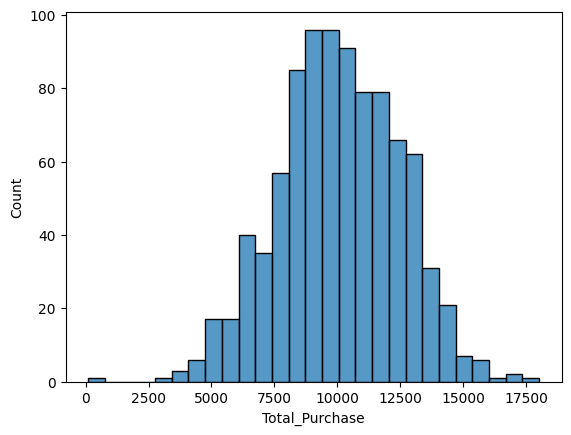

In [128]:
sns.histplot(df['Total_Purchase'])

<Axes: xlabel='Log_Total_Purchase', ylabel='Count'>

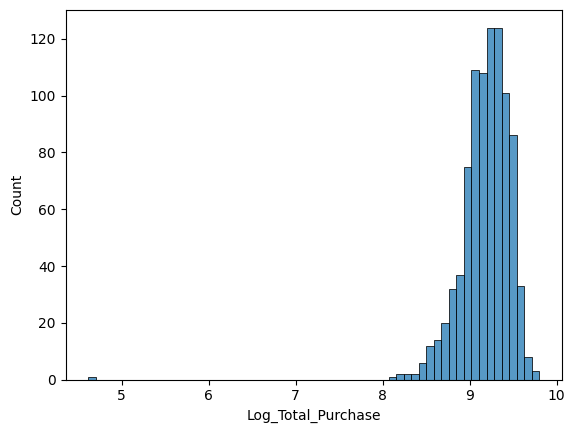

In [129]:
sns.histplot(df['Log_Total_Purchase'])

In [130]:
df['Years_Squared'] = df['Years'] ** 2

In [131]:
df[['Years_Squared','Years']]

,Years_Squared,Years
0,52.1284,7.22
1,42.2500,6.50
2,44.4889,6.67
3,45.0241,6.71
4,30.9136,5.56
...,...,...
895,13.1044,3.62
896,47.7481,6.91
897,29.8116,5.46
898,29.9209,5.47


<Axes: xlabel='Years_Squared', ylabel='Count'>

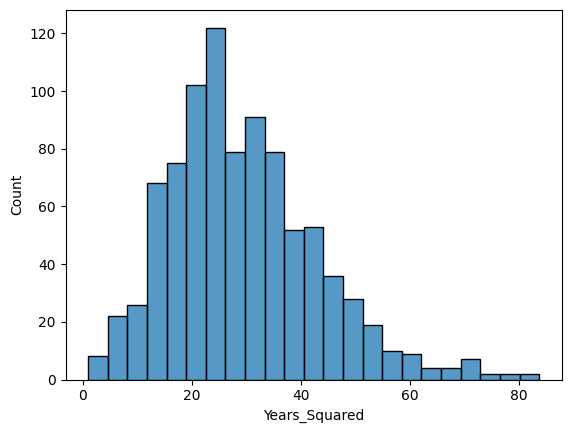

In [132]:
sns.histplot(df['Years_Squared'])

A polynomial feature is created by raising an existing feature to a power (such as x² or x³) to help a model learn non-linear relationships.

Data leakage occurs when information unavailable at prediction time is included in the training data, causing overly optimistic model performance.

## Leakage Check

Age → Safe

Total_Purchase → Safe

Account_Manager → Safe

Years → Safe

Num_Sites → Safe

Onboard_date → Safe

No obvious leakage detected.

In [133]:
from sklearn.model_selection import train_test_split

In [134]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [135]:
X.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,tenure_group,Years_x_sites,Log_Total_Purchase,Years_Squared
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,old,57.76,9.311795,52.1284
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,old,71.50,9.385740,42.2500
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",old,80.04,9.463877,44.4889


In [136]:
y.head(3)

0    1
1    1
2    1
Name: Churn, dtype: int64

In [137]:
X_train,X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42
)

In [138]:
X_test.shape

(180, 13)

In [139]:
X_train.shape

(720, 13)

Now we will make the Pipeline 

In [140]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [141]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_group,Years_x_sites,Log_Total_Purchase,Years_Squared
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76,9.311795,52.1284


In [142]:
numeric_features = [
    'Age', 'Total_Purchase', 'Years', 'Num_Sites'
]

categorical_features = [
    'Account_Manager'
]

In [143]:
preprocessor = ColumnTransformer(
    transformers=[(
        'num',
        StandardScaler(),
        numeric_features
    ),
    (
        'cat',
        OneHotEncoder(drop='if_binary'),
        categorical_features
    )
    ]
)

In [144]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [145]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])

In [146]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [147]:
pred = pipeline.predict(X_test)

In [148]:
print(pred)

[0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0]


In [149]:
pred[:10]

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 1])

The Model has start giving predictions but we now need to check how accurate it is.


In [150]:
from sklearn.metrics import accuracy_score

In [151]:
accu = accuracy_score(y_test,pred)

In [152]:
accu

0.9

90% accuracy looks good but we need to check more matrix

In [153]:
from sklearn.metrics import confusion_matrix

In [154]:
confusion_matrix(y_test,pred)

array([[142,   6],
       [ 12,  20]])

In [155]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.77      0.62      0.69        32

    accuracy                           0.90       180
   macro avg       0.85      0.79      0.82       180
weighted avg       0.89      0.90      0.90       180

